# Sparseness Optimized Feature Importance for images

SOFI searches for an order of image segments whose cumulative marginalization degrades the
response of a classifier as fast as possible. A ranking is judged through its degradation
score, namely the area between the curve obtained when the least relevant segments are removed
first and the one obtained when the most relevant segments are removed first. Maximizing that
area rewards sparsity and faithfulness at once, so the explanation isolates the smallest set of
segments that changes the decision.

The notebook has two parts. The first shows the basic pipeline from end to end, namely loading
the data, building a model, setting up the explainer and inspecting the explanation of one
image. The second shows the experimentation the package supports once that pipeline is in
place, where a setting is varied and its effect measured.

The classifier is written in TensorFlow and Keras. The explainer is agnostic to the framework
and recognizes PyTorch modules, the backbones of `torchvision` and `timm` and the image models
of `transformers` in exactly the same way, as the documentation describes, so one framework is
enough to show how it is used.

Chest radiographs serve as the case study. Anything specific to them is marked as such, since
the package makes no assumption about the domain.

In [1]:
import os
import warnings

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import sofiimg
from sofiimg import Experiment, SOFIExplainer, load_dataset

SEED = 42
np.random.seed(SEED)
print("sofiimg", sofiimg.__version__)

sofiimg 1.0.0


## Part 1. The basic pipeline

### Loading the data

`load_dataset` reads the images as they sit on disk and nothing else. No resizing, no scaling
and no normalization take place inside the package, because the preprocessing belongs to the
model rather than to the explainer. SOFI marginalizes a segment of the array the model
receives, so the array the explainer holds has to be the array the model was fitted on.

The bundled sample pairs chest radiographs from the paediatric collection of Guangzhou Women
and Children's Medical Center with the lung annotations that the v7 Labs COVID-19 X-ray dataset
published for them. Masks of that kind are optional and specific to this case study, and their
purpose is explained in Part 2.

In [2]:
data = load_dataset("pneumonia")
print(data.summary())
print(pd.Series(data.y_train).value_counts().to_string())

pneumonia, 2 classes, 2532 train and 634 test images, 224 by 224 pixels, 1 channel(s), with lung masks [bundled]
PNEUMONIA    1268
NORMAL       1264


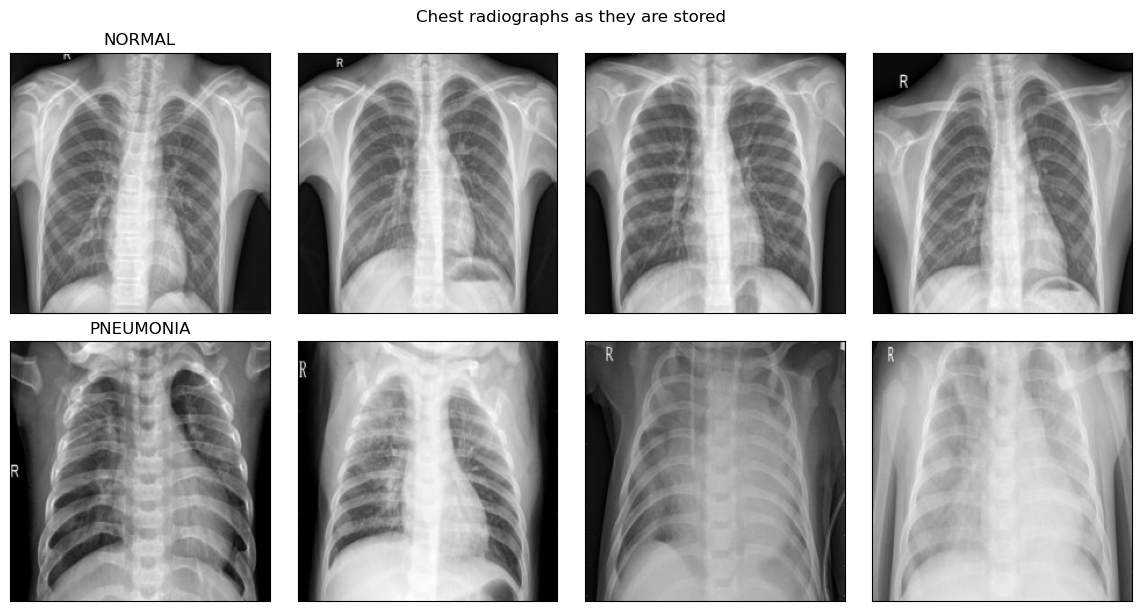

In [3]:
figure, axes = plt.subplots(2, 4, figsize=(11.5, 6.0), layout="constrained")
for row, label in enumerate(data.classes):
    positions = np.flatnonzero(data.y_test == label)[:4]
    for column, position in enumerate(positions):
        axes[row, column].imshow(data.X_test[position], cmap="gray")
        axes[row, column].set_xticks([]); axes[row, column].set_yticks([])
        axes[row, column].grid(False)
        axes[row, column].set_title(label if column == 0 else "")
figure.suptitle("Chest radiographs as they are stored")
plt.show()

### Preprocessing

The preprocessing lives in the notebook, it is applied once, and both the model and the
explainer are built on its output. Applying the lung mask here is the case study speaking. A
problem without a meaningful region of interest simply skips that argument.

In [4]:
SIZE = 96

def preprocess(images, masks=None, size=SIZE, channels=1):
    # resize, scale and shape a batch, optionally keeping a region of interest
    # alone. The same routine serves the training data, the test data and every
    # image that is later explained, which keeps the model and the explainer in
    # step. Raising the channel count to three is all a network pretrained on
    # natural images needs, so one routine covers that case as well
    if masks is not None:
        images = images * masks
    resized = np.stack(
        [
            np.asarray(Image.fromarray(p.astype("uint8")).resize((size, size), Image.BILINEAR))
            for p in images
        ]
    )
    return np.repeat((resized.astype("float32") / 255.0)[..., None], channels, axis=-1)

def shrink(masks, size=SIZE):
    # a mask carries labels rather than intensities, so nearest neighbor sampling
    # is the only admissible rule
    return np.stack(
        [
            np.asarray(Image.fromarray(m.astype("uint8") * 255).resize((size, size), Image.NEAREST)) > 127
            for m in masks
        ]
    )

raw_train = preprocess(data.X_train, data.masks_train)
raw_test = preprocess(data.X_test, data.masks_test)
CENTER, SPREAD = float(raw_train.mean()), float(raw_train.std())

X_train = (raw_train - CENTER) / SPREAD
X_test = (raw_test - CENTER) / SPREAD
M_train, M_test = shrink(data.masks_train), shrink(data.masks_test)
y_train, y_test = data.codes(data.y_train), data.codes(data.y_test)

print("model input", X_train.shape, "masks", M_train.shape, "classes", data.classes)

model input (2532, 96, 96, 1) masks (2532, 96, 96) classes ['NORMAL', 'PNEUMONIA']


### Building the model

Any classifier that yields class probabilities can be explained. The convolutional network
below is written in TensorFlow and Keras and is never declared to the explainer, which resolves
the framework, the channel layout and the output convention on a probe batch.

In [5]:
import tensorflow as tf
import keras

print("tensorflow", tf.__version__, "keras", keras.__version__, keras.backend.backend())
def build_model(size=SIZE, channels=1, seed=SEED):
    # the architecture is written once and rebuilt whenever a model is needed,
    # so the comparison later in the notebook differs in its data alone
    keras.utils.set_random_seed(seed)

    def block(x, width):
        x = keras.layers.Conv2D(width, 3, padding="same")(x)
        x = keras.layers.GroupNormalization(groups=4)(x)
        x = keras.layers.Activation("relu")(x)
        return keras.layers.MaxPooling2D()(x)

    entry = keras.layers.Input((size, size, channels))
    hidden = block(entry, 16)
    hidden = block(hidden, 32)
    hidden = block(hidden, 64)
    hidden = block(hidden, 64)
    hidden = keras.layers.GlobalAveragePooling2D()(hidden)
    model = keras.Model(entry, keras.layers.Dense(2, activation="softmax")(hidden))
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def train(model, inputs, targets, epochs=12):
    model.fit(
        inputs, targets, epochs=epochs, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.LearningRateScheduler(
            lambda epoch, lr: 1e-3 * 0.5 * (1 + np.cos(np.pi * epoch / epochs))
        )],
    )
    return model

model = train(build_model(), X_train, y_train)
accuracy = float(model.evaluate(X_test, y_test, verbose=0)[1])
print(f"test accuracy {accuracy:.3f}")

tensorflow 2.20.0 keras 3.13.2 tensorflow
test accuracy 0.916


### Setting up the explainer

Three decisions configure an explanation. The segmentation declares what the explanation may
name, the marginalization declares what neutralizing a segment means, and the search budget
declares how hard to look. Part 2 measures what each of them does.

In [6]:
explainer = SOFIExplainer(
    model,
    X_train,
    y_train,
    classes=data.classes,
    segmentation="slic",
    segmentation_params={"n_segments": 40, "compactness": 0.2, "sigma": 1.0},
    marginalization="lowneg",
    max_iterations=120,
    n_restarts=1,
    patience=40,
    batch_size=64,
    random_state=SEED,
)

[sofiimg] backend keras, 2 classes, channels_first=False, output=proba


### Inspecting one explanation

`explain` receives the image itself and returns an explanation that carries its own figures.
The mask and the original are optional, the first confining the explanation to a region of
interest and the second giving the figures something better to draw than the downscaled array
the model receives.

The image below was chosen by hand from the confident pneumonia cases. Being classified
correctly is not enough, since a curve is readable only when the response falls as segments are
removed and does not climb back once they are all gone, and Part 2 reports the two figures that
settle it.

In [7]:
POSITION = 582      # chosen by hand from the confident pneumonia cases

explanation = explainer.explain(
    X_test[POSITION],               # the image itself
    mask=M_test[POSITION],          # the segment of interest, optional
    display=data.X_test[POSITION],  # the original, drawn in every figure
)
print(explanation.summary(top_k=8))

SOFI explanation
  explained class           PNEUMONIA
  segmentation              slic, 37 segments
  marginalization           the matching pixels of a reference drawn from the 10 lowest scoring images, which the model scores 0.0054
  reading                   Segments are ranked by how quickly they move the model away from the explained class, which is a counterfactual reading rather than a reliance reading.
  degradation score         0.5977
  response drop             0.962
  terminal surge            0.039
  area under MoRF           0.3079
  area under LeRF           0.9056
  unperturbed probability   0.9997
  class change              after 11 of 37 segments, rate 0.297, against step 35 under LeRF
  noise region              none detected
  modularity gap            0.9143, segment effects are conditional
  search                    120 iterations, 0 restarts, 121 evaluations, 244 model queries
  ranking                   1. s32, 2. s7, 3. s13, 4. s2, 5. s30, 6. s14, 7. s16, 8.

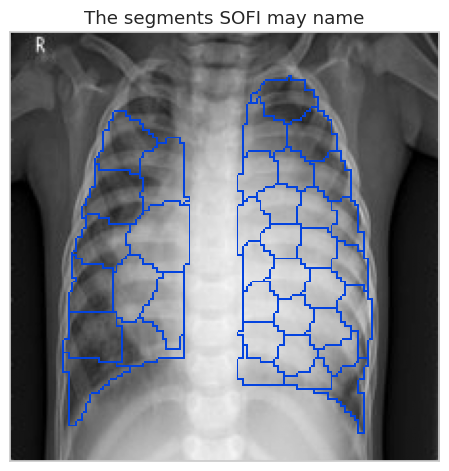

In [8]:
explanation.plot_segmentation(title="The segments SOFI may name")
plt.show()

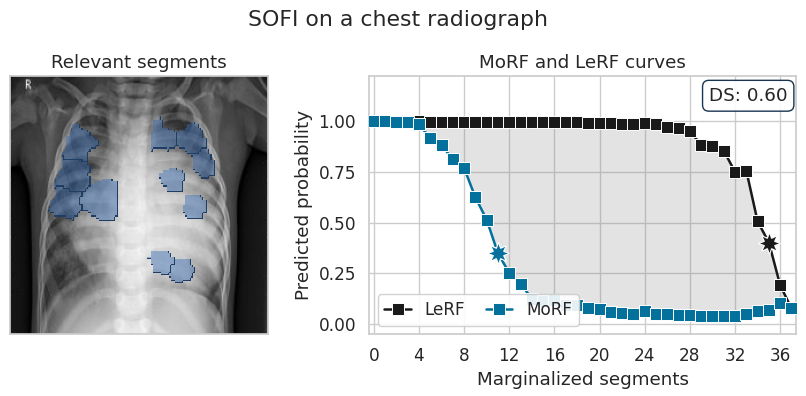

In [9]:
explanation.plot_explanation(title="SOFI on a chest radiograph")
plt.show()

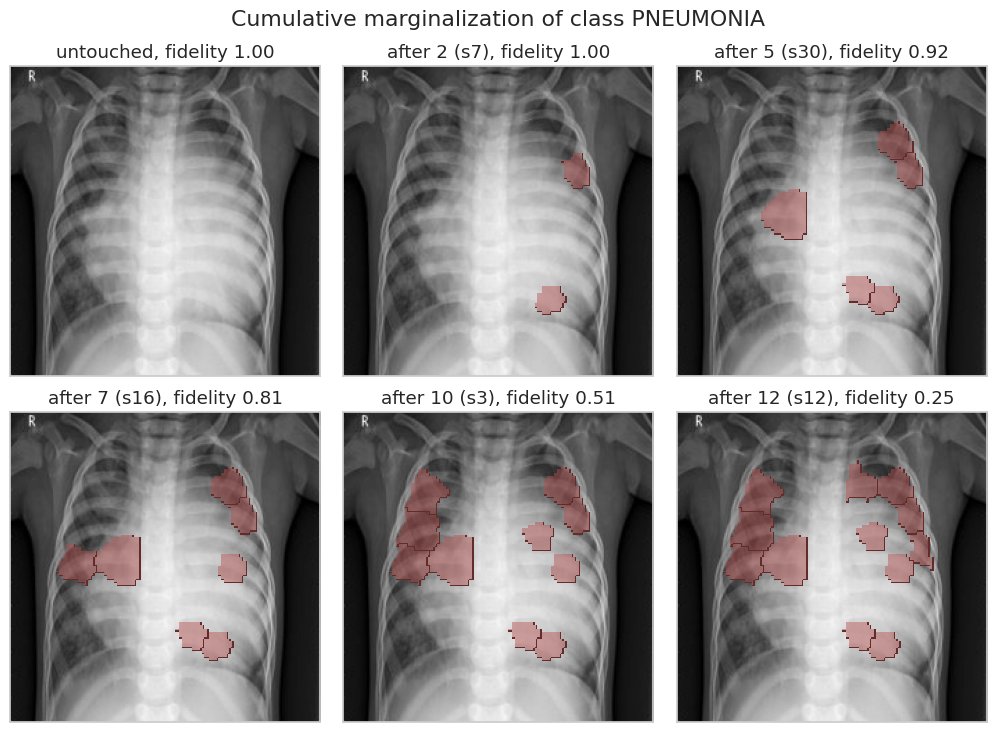

In [10]:
explanation.plot_marginalization(ncols=3, color="#b64f4f", figsize=(10,5))
plt.show()

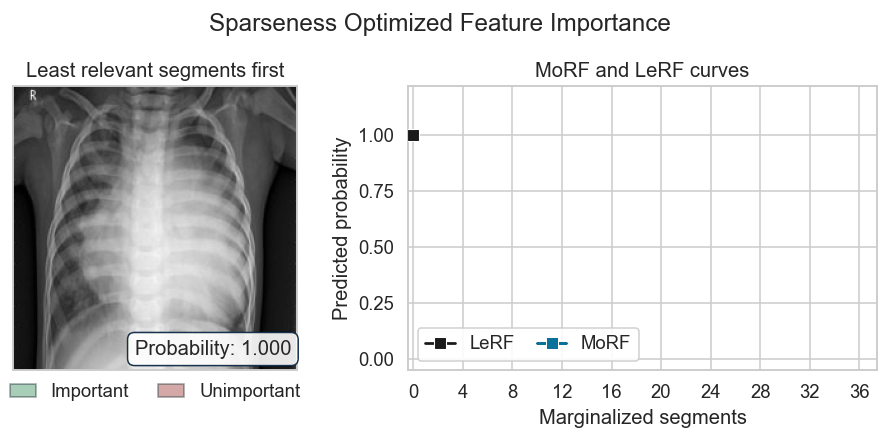

In [12]:
explanation.plot_animation(figsize=(8,4))

That is the whole pipeline, and nothing else is needed to explain an image. Everything below varies one setting at a time and measures the
effect, which is useful when an explanation has to be defended rather than merely produced.

## Part 2. Experimentation

`Experiment` is the advanced half of the package. It explains batches and varies one setting at
a time, returning a table and drawing one figure per setting, which is what an author needs
when an explanation has to be defended rather than merely produced. It is built from the
explainer alone, and every study receives the image it runs on.

### Why this case study masks the lungs

This section is specific to chest radiographs and does not generalize. A classifier trained on
unrestricted images can settle on signals outside the pulmonary parenchyma, namely positioning
cues, soft tissue beyond the thorax and border artifacts. An explainer applied to such a model
reports those signals faithfully and the explanation is useless to a clinician. Passing a mask
confines both the segmentation and the ranking to the anatomy, so nothing outside it can be
named. Other problems need no mask at all, and the same argument would apply to a watermark in
a product photograph or a timestamp burned into a frame.

The comparison below needs its own code, since it trains a second model.

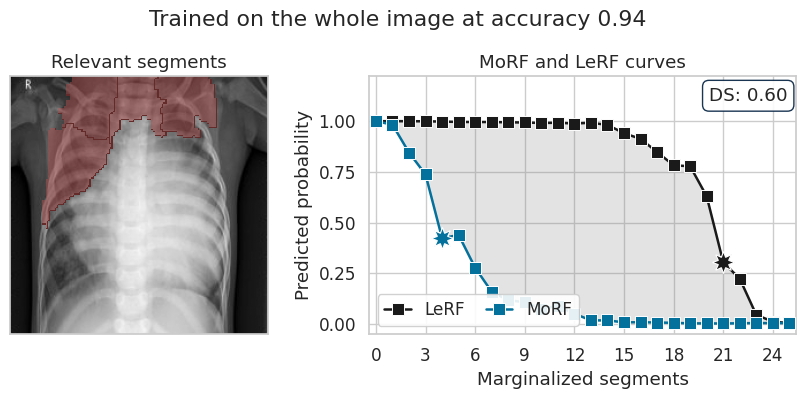

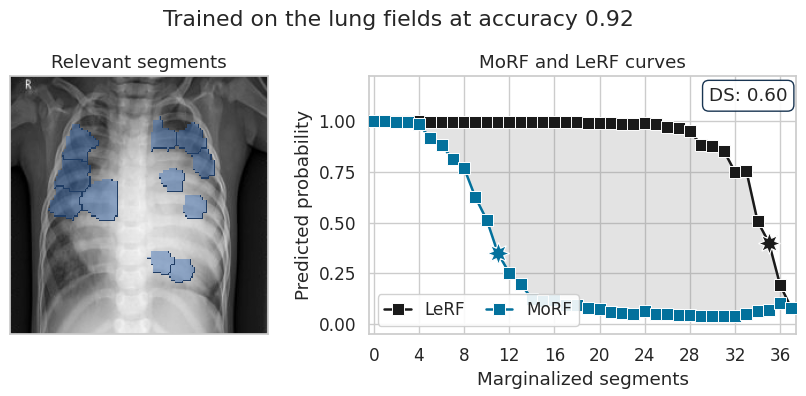

62% of the pixels the unrestricted model relies on lie outside the lungs


In [13]:
whole_train = (preprocess(data.X_train) - CENTER) / SPREAD
whole_test = (preprocess(data.X_test) - CENTER) / SPREAD

whole_model = train(build_model(), whole_train, y_train)
whole_accuracy = float(whole_model.evaluate(whole_test, y_test, verbose=0)[1])

whole_explainer = SOFIExplainer(
    whole_model, whole_train, y_train, classes=data.classes, segmentation="slic",
    segmentation_params={"n_segments": 30, "compactness": 0.2},
    marginalization="lowneg", max_iterations=120, batch_size=64,
    random_state=SEED, verbose=False,
)
unrestricted = whole_explainer.explain(whole_test[POSITION], display=data.X_test[POSITION])

unrestricted.plot_explanation(
    title=f"Trained on the whole image at accuracy {whole_accuracy:.2f}", color="#b64f4f", 
)
plt.show()
explanation.plot_explanation(
    title=f"Trained on the lung fields at accuracy {accuracy:.2f}", color="#3b6fb6", 
)
plt.show()

outside = float(np.mean([
    (~M_test[POSITION])[unrestricted.segmentation[i].rows, unrestricted.segmentation[i].cols].mean()
    for i in unrestricted.order[: max(1, unrestricted.sparsity_point or 5)]
]))
print(f"{outside * 100:.0f}% of the pixels the unrestricted model relies on lie outside the lungs")

### How many segments

The segment count is the most consequential setting and more is not simply better.

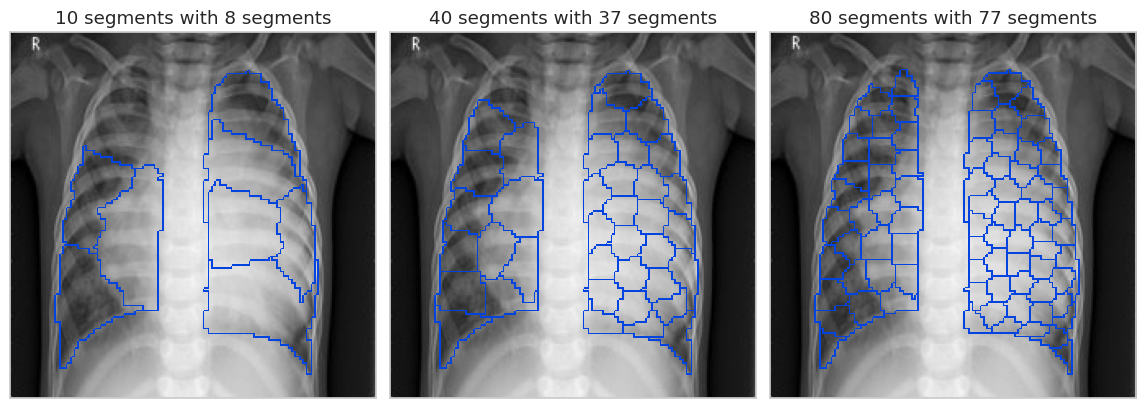

,setting,segments,ds,share_named,drop,surge,sparsity_rate,flip_after,queries,seconds
0,10 segments,8,0.3248,0.597,0.862,0.000,0.625,5,172,7.3
1,20 segments,18,0.4229,0.462,0.929,0.045,0.500,9,236,11.0
2,40 segments,37,0.5977,0.328,0.962,0.039,0.297,11,244,20.0
3,60 segments,58,0.5504,0.258,0.978,0.025,0.259,15,244,39.5
4,80 segments,77,0.5995,0.217,0.980,0.025,0.208,16,244,39.5


In [27]:
study = Experiment(explainer, random_state=SEED)
picked = dict(mask=M_test[POSITION], display=data.X_test[POSITION])

study.segmentation_grid(X_test[POSITION], counts=(10, 40, 80), **picked)
plt.show()
study.segment_counts(X_test[POSITION], [10, 20, 40, 60, 80], plot=False, **picked)

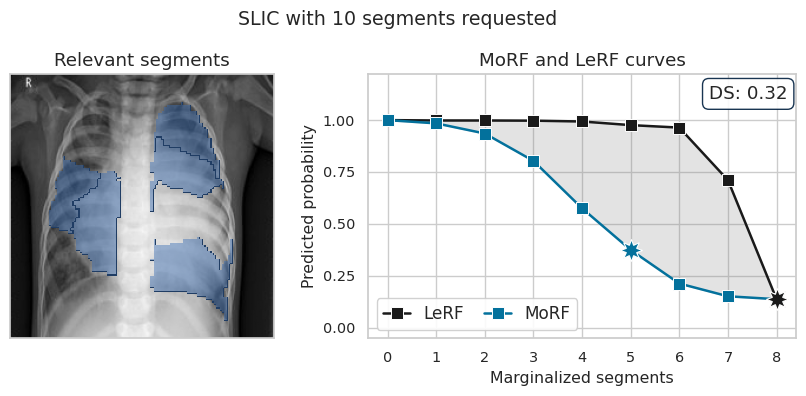

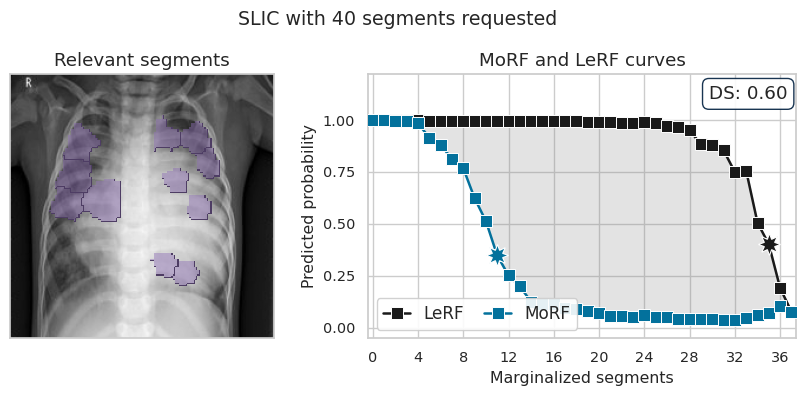

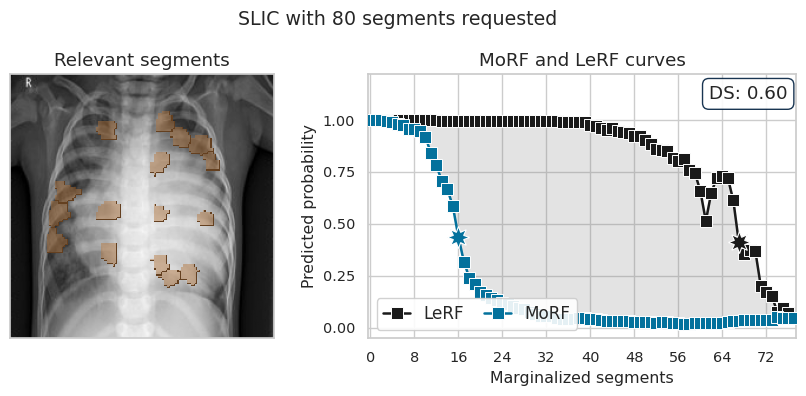

,setting,segments,ds,share_named,drop,surge,sparsity_rate,flip_after,queries,seconds
0,10 segments,8,0.3248,0.597,0.862,0.000,0.625,5,172,11.0
1,40 segments,37,0.5977,0.328,0.962,0.039,0.297,11,244,30.6
2,80 segments,77,0.5995,0.217,0.980,0.025,0.208,16,244,39.6


In [30]:
# whatever a study holds fixed is named, and everything else reaches the figures
study.segment_counts(X_test[POSITION], [10, 40, 80], **picked, figsize=(8, 4), font_scale=0.95)

Refining the partition shrinks the share of the image the explanation names, which is the
reason to refine at all, while the runtime and the query count grow and the search covers an
ever smaller fraction of a larger space. The degradation score climbs with the count almost
mechanically, since a finer partition offers more freedom to separate the two curves, so scores
obtained under different partitions are not comparable and the column cannot arbitrate.

### How compact the segments are

`compactness` weighs the spatial term against the intensity term. A large value gives squarer
segments that follow the image less, and a small one gives segments that hug the contours.

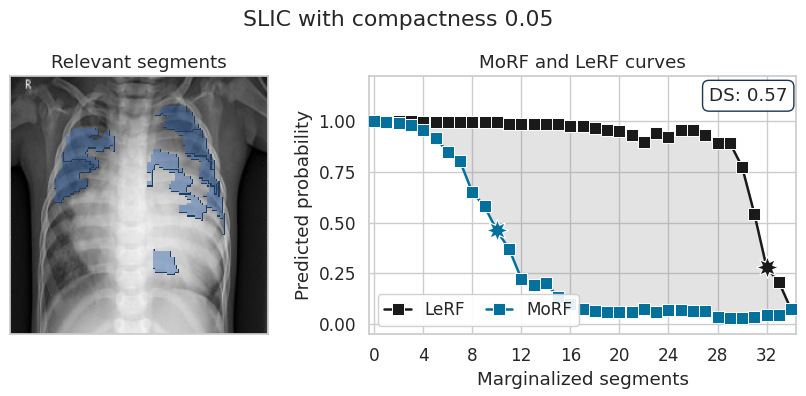

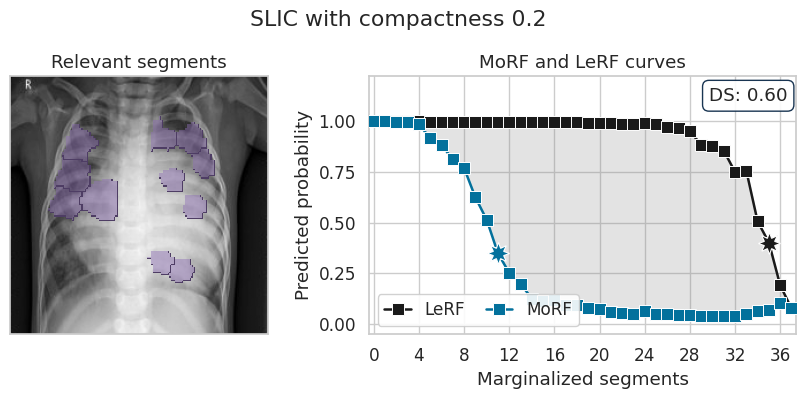

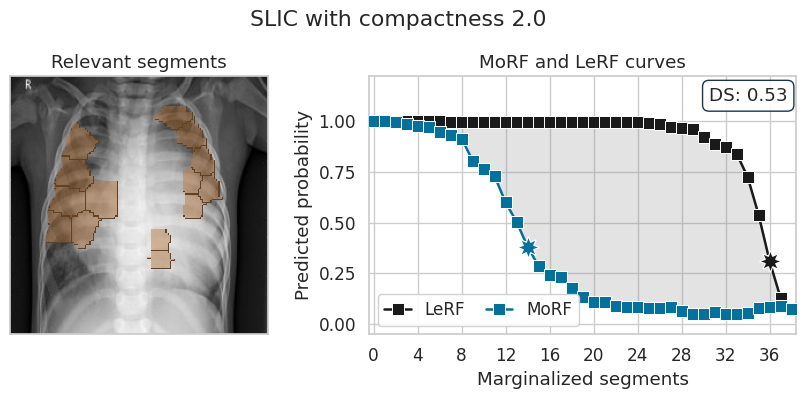

,setting,segments,ds,drop,surge,sparsity_rate,flip_after,queries,seconds
0,compactness 0.05,34,0.5739,0.971,0.043,0.294,10,244,28.7
1,compactness 0.2,37,0.5977,0.962,0.039,0.297,11,244,29.8
2,compactness 2.0,38,0.5289,0.951,0.026,0.368,14,244,25.6


In [32]:
study.compactness(X_test[POSITION], [0.05, 0.2, 2.0], figsize=(8, 4), **picked)

### What neutralizing a segment means

Fifteen operators are available in two families. A class agnostic one erases a segment without
steering the prediction anywhere, and its ranking answers which segments the prediction relies
on. A class directed one chooses the substitution so that the response falls fastest, and its
ranking answers which segments move the model away from the current class, which is a
counterfactual question. Every explanation states which family produced it.

In [33]:
operators = study.operators(
    X_test[POSITION],
    ["mean", "zero", "blur", "inpaint", "segment_mean", "road", "noise",
     "background", "lowneg", "line_search"],
    plot=False, **picked,
)
operators.sort_values("ds", ascending=False).reset_index(drop=True)

,setting,family,segments,ds,drop,surge,sparsity_rate,flip_after,queries,seconds
0,lowneg,directed,37,0.5977,0.962,0.039,0.297,11.0,244,28.7
1,mean,agnostic,37,0.5680,0.937,0.936,0.270,10.0,242,28.4
2,zero,agnostic,37,0.5680,0.937,0.936,0.270,10.0,242,26.6
3,line_search,directed,37,0.4998,0.894,0.873,0.081,3.0,244,29.4
4,background,agnostic,37,0.3357,0.607,0.116,0.405,15.0,242,215.4
5,noise,agnostic,37,0.2136,0.997,0.000,0.081,3.0,242,75.7
6,blur,agnostic,37,0.0026,0.005,0.005,1.000,NaN,242,22.4
7,road,agnostic,37,0.0006,0.001,0.001,1.000,NaN,242,25.3
8,inpaint,agnostic,37,0.0003,0.000,0.000,1.000,NaN,244,22.6
9,segment_mean,agnostic,37,0.0001,0.000,0.000,1.000,NaN,244,32.3


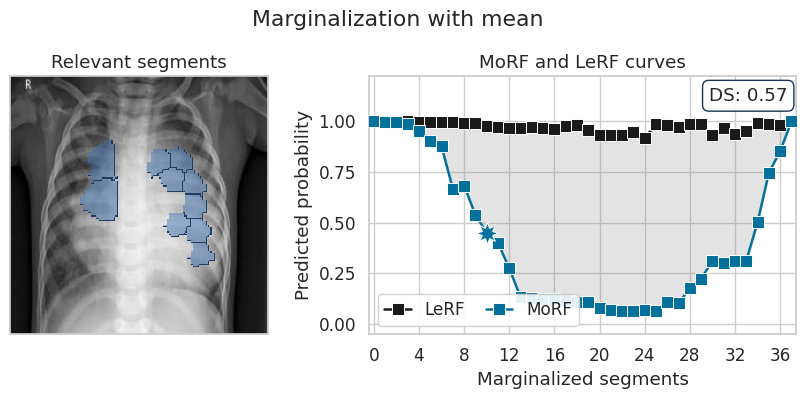

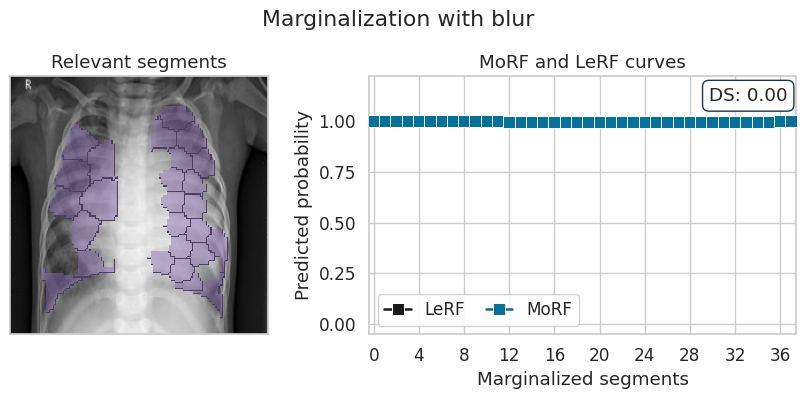

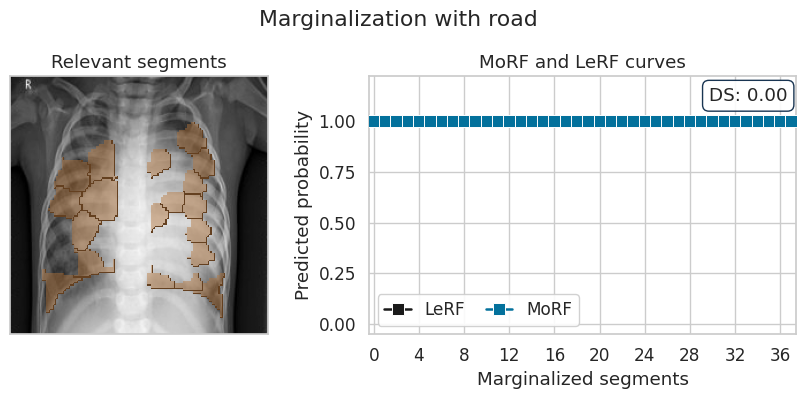

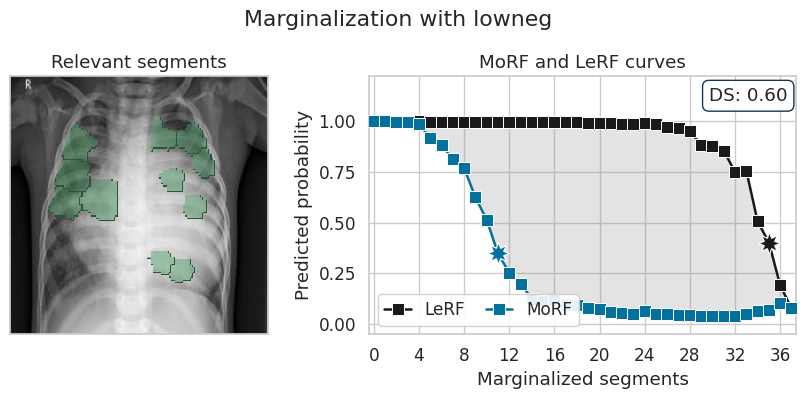

,setting,family,segments,ds,drop,surge,sparsity_rate,flip_after,queries,seconds
0,mean,agnostic,37,0.5680,0.937,0.936,0.270,10.0,242,20.1
1,blur,agnostic,37,0.0026,0.005,0.005,1.000,NaN,242,18.4
2,road,agnostic,37,0.0006,0.001,0.001,1.000,NaN,242,19.4
3,lowneg,directed,37,0.5977,0.962,0.039,0.297,11.0,244,18.3


In [34]:
study.operators(X_test[POSITION], ["mean", "blur", "road", "lowneg"], figsize=(8, 4), **picked)

Read the drop column before the score. An operator that leaves the response within a thousandth
of where it began still produces a pair of curves, and the area between them can be large while
nothing has been removed. Then read the surge, which is how far the response climbs back once
every segment is gone. A flat image or a uniformly blurred one is not a radiograph with pieces
missing, it is a different kind of object, and the response of the model there owes nothing to
the evidence taken away.

Both failures are properties of the image as much as of the operator, so an operator that looks
inert on one image may work on the next. `marginalization="auto"` screens on both figures
before comparing any area, discarding a candidate that falls by less than `min_drop` or ends
above `surge_tolerance` and maximizing the score among what survives.

In [35]:
automatic = SOFIExplainer(
    model, X_train, y_train, classes=data.classes, segmentation="slic",
    segmentation_params={"n_segments": 40, "compactness": 0.2},
    marginalization="auto", max_iterations=80, batch_size=64,
    random_state=SEED, verbose=False,
).explain(X_test[POSITION], mask=M_test[POSITION])

print("operator selected automatically,", automatic.perturbation["operator"])
print(f"   degradation score {automatic.ds:.4f}, drop {automatic.drop:.3f}, surge {automatic.surge:.3f}")
pd.DataFrame(automatic.perturbation["trials"])[
    ["operator", "ds", "drop", "surge", "admissible", "sparsity_rate"]
]

operator selected automatically, lowneg
   degradation score 0.5529, drop 0.956, surge 0.033


,operator,ds,drop,surge,admissible,sparsity_rate
0,constant,0.475580,0.909256,0.908412,False,0.270270
1,constant,0.547749,0.986175,0.982331,False,0.135135
2,constant,0.506214,0.913290,0.891897,False,0.081081
3,blur,0.002048,0.004768,0.004760,False,1.000000
4,segment_mean,0.000140,0.000128,0.000099,False,1.000000
5,road,0.000638,0.000772,0.000754,False,1.000000
6,lowneg,0.552851,0.956289,0.033330,True,0.297297


### Against rankings obtained elsewhere

Any method that ends in an order of segments can be measured on the same terms. Feature
occlusion and a random order are included as the standard upper and lower references, and a
pixel-wise saliency map joins them once it has been averaged inside each segment.

In [36]:
with tf.GradientTape() as tape:
    pixels = tf.convert_to_tensor(X_test[POSITION][None, ...])
    tape.watch(pixels)
    score = model(pixels)[0, explanation.label]
saliency = np.abs(tape.gradient(score, pixels).numpy()[0, ..., 0])

study.rankings(X_test[POSITION], saliency={"Input gradient": saliency}, plot=False, **picked)

,setting,segments,ds,drop,surge,sparsity_rate,flip_after,queries,seconds
0,SOFI,37,0.5977,0.962,0.039,0.297,11,4,2.0
1,Occlusion,37,0.4147,0.923,0.000,0.378,14,4,1.8
2,Random,37,-0.0509,0.923,0.000,0.730,27,4,1.7
3,Input gradient,37,-0.2184,0.923,0.000,0.838,31,4,1.8


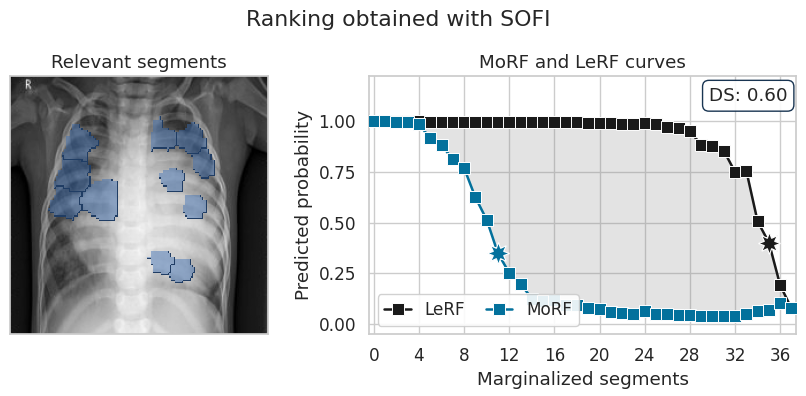

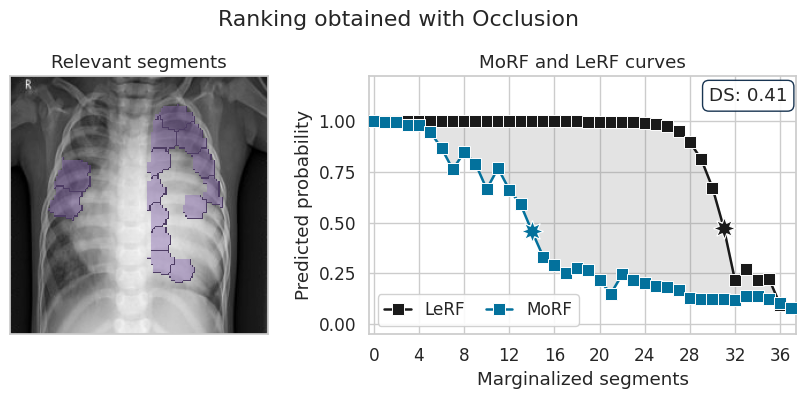

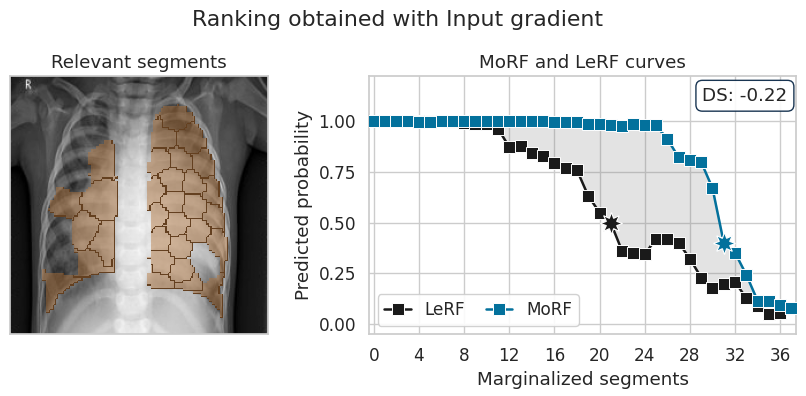

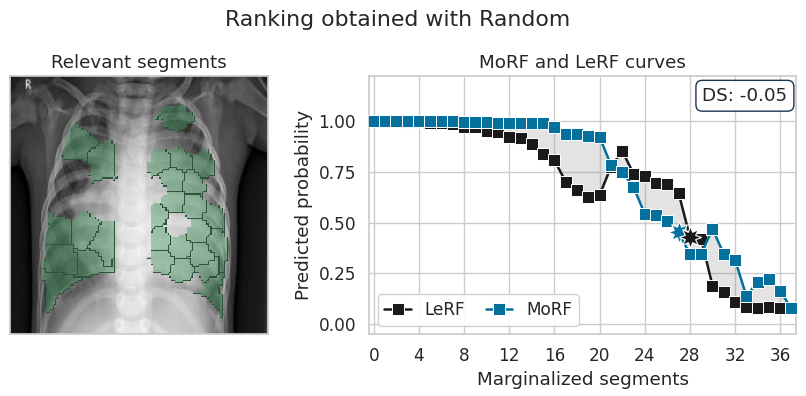

,setting,segments,ds,drop,surge,sparsity_rate,flip_after,queries,seconds
0,SOFI,37,0.5977,0.962,0.039,0.297,11,4,1.2
1,Occlusion,37,0.4147,0.923,0.000,0.378,14,4,1.2
2,Random,37,-0.0509,0.923,0.000,0.730,27,4,1.2
3,Input gradient,37,-0.2184,0.923,0.000,0.838,31,4,1.2


In [38]:
study.rankings(X_test[POSITION], saliency={"Input gradient": saliency}, figsize=(8, 4), **picked)

A negative degradation score says the MoRF curve sits above the LeRF curve, so the ranking is
worse than no ranking at all. The raw axis makes that visible, which a rescaled one could not.